In [1]:
# setup and load libraries
import numpy as np
import sys, cv2, time, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import MNIST
from inverse.orthogonal import LinearInverse, GaussianLinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ExponentialLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                "axes.grid": False, "figure.facecolor": "white"}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Set Up Data

In [3]:
data = MNIST()
train_set = data.train_set()
test_set = data.test_set()

In [4]:
test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [5]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)
avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [6]:
model_path = './assets/unet_mnist.pt'
model = init_UNet({'num_blocks':2})
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

In [7]:
loss = torch.nn.MSELoss(reduction='sum')
def compute_loss(recon, test, test_torch):
    mse_val = (loss(test_torch, recon) / recon.shape[0]).item()
    recon_numpy = recon.permute([0, 2, 3, 1]).detach().cpu().numpy()
    psnr_val = psnr(test, recon_numpy)
    
    return mse_val, psnr_val

### Measurement Matrix

In [8]:
# load matrix
n_sample = 32
file_path = './olm_2025/MNIST/all_digit/%d_MSE_mnist.npy' % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)
        
opt_mtx = torch.from_numpy(opt_mtx)

In [9]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_

In [10]:
pca_mtx = torch.from_numpy(pca.components_[:n_sample, :])
rnd_mtx = torch.rand(n_sample, np.prod(im_size))
print(pca_mtx.shape, rnd_mtx.shape)

torch.Size([32, 784]) torch.Size([32, 784])


In [11]:
solver = GaussianLinearInverse(n_sample, im_size, model, avg_im)
solver = solver.to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True
solver.num_avg = 16
solver.assign(pca_mtx.to(device))

solver_gpu = torch.nn.DataParallel(solver)
recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

mse_val, psnr_val = compute_loss(recon, test_numpy, test_torch)

### Measurement with Additive Noise 

In [12]:
solver = GaussianLinearInverse(n_sample, im_size, model, avg_im)
solver = solver.to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True
solver.num_avg = 16

all_mtx = [pca_mtx, opt_mtx, rnd_mtx]

In [13]:
noise_sigma = [0.0125, 0.025, 0.05, 0.1, 0.2, 0.4, 0.8]
psnr_vals = np.zeros([3, len(noise_sigma)])
for idx in range(len(noise_sigma)):
    for idy in range(len(all_mtx)):
        sys.stdout.write(f"\r {idx} - {idy}")
        sys.stdout.flush()
        
        solver.noise_sd = noise_sigma[idx]
        solver.assign(all_mtx[idy].to(device))
        solver_gpu = torch.nn.DataParallel(solver)
    
        recon = batch_recon(test_torch, solver_gpu, batch_size=32)
        mse_val, psnr_val = compute_loss(recon, test_numpy, test_torch)    
        psnr_vals[idy, idx] = np.array(psnr_val)

 6 - 2

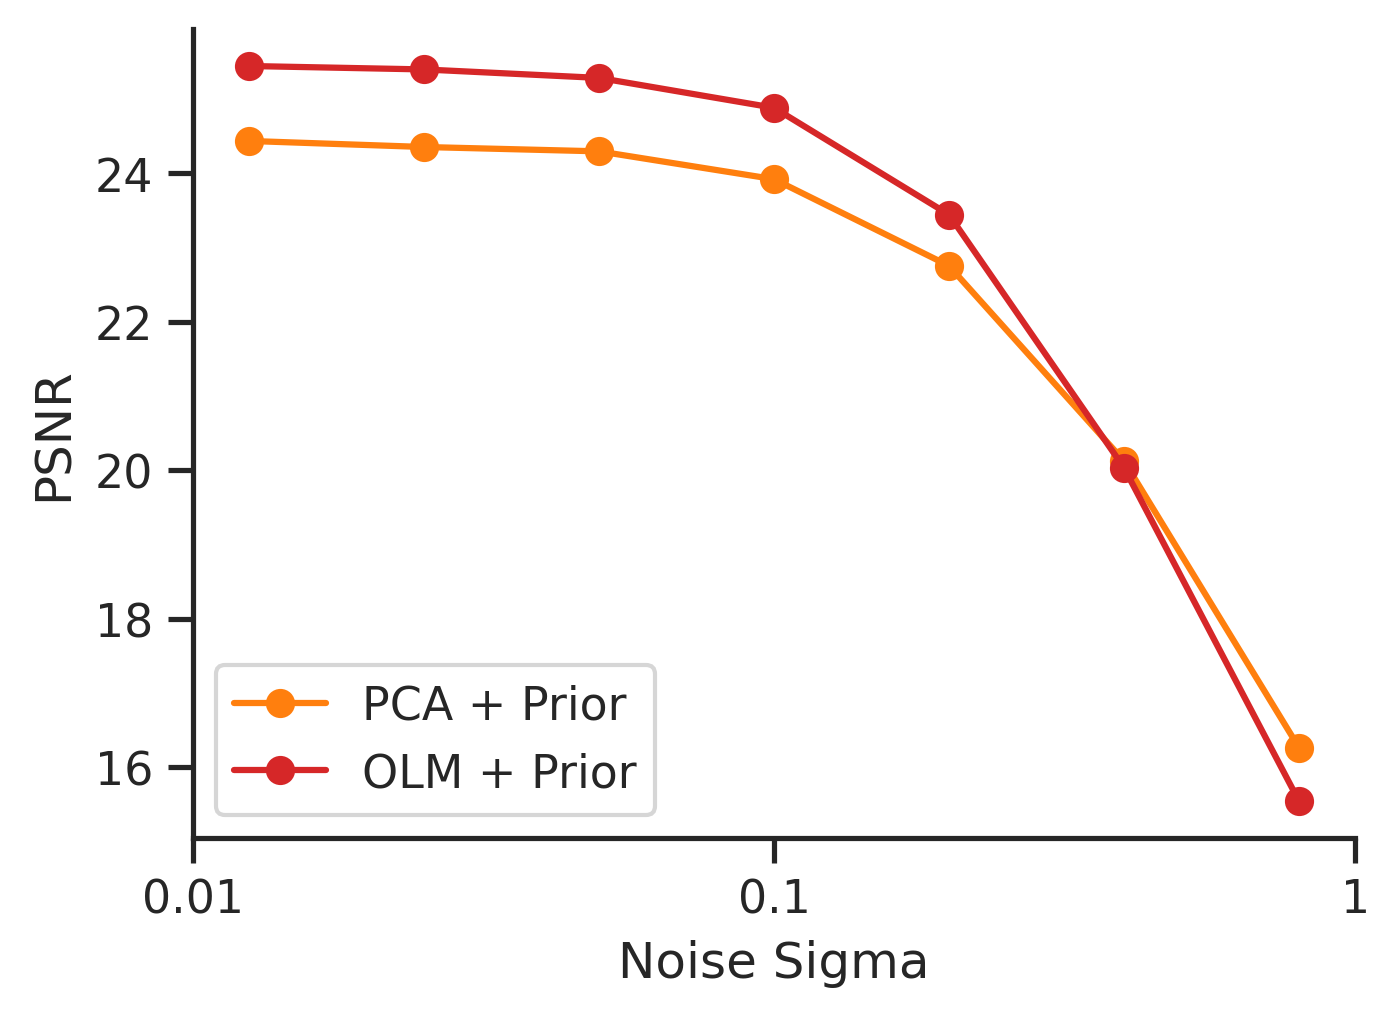

In [14]:
fig = plt.figure(figsize=(5, 3.5))
ax = plt.subplot()

plt.plot(noise_sigma, psnr_vals[0, :], 
         '-o', color='tab:orange', label='PCA + Prior')
plt.plot(noise_sigma, psnr_vals[1, :], 
         '-o', color='tab:red', label='OLM + Prior')

plt.xscale('log')
plt.xlabel('Noise Sigma')
plt.ylabel('PSNR')
plt.minorticks_off()
plt.xticks([0.01, 0.1, 1])
ax.set_xticklabels(([0.01, 0.1, 1]))
plt.legend()

plt.show()
fig.savefig('additive_noise.pdf', format='pdf', bbox_inches='tight')

### Optimization with Added Noise

In [15]:
loss = torch.nn.MSELoss(reduction='sum').to(device)
train = train_torch
test = test_torch
batch_size = 256
n_epoch = 16
lr = 1e-3
gamma = 0.90

In [16]:
solver = GaussianLinearInverse(n_sample, im_size, model, avg_im)
solver = solver.to(device)
solver.max_t = 128
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True
solver.num_avg = 2
solver.noise_sd = 0.4

# init with OLM (optional)
# solver.assign(opt_mtx.to(device))
solver_gpu = torch.nn.DataParallel(solver)

In [17]:
# training data
n_batch = np.ceil(train.shape[0] / batch_size)
train_data = DataLoader(train, batch_size, shuffle=True,
                        num_workers=8, pin_memory=True)

# optimizers
optim = torch.optim.Adam(solver.parameters(), lr=lr)
scheduler = ExponentialLR(optim, gamma=gamma, verbose=False)

batch_loss = []
epoch_loss = []

# Run n_epoch of training
for epoch in range(n_epoch):
    start_time = time.time()
    total_loss = 0.0

    # SGD Optimization
    for count, batch in enumerate(train_data):
        optim.zero_grad(set_to_none=True)
        batch = batch.permute(0, 3, 1, 2).contiguous().to(device)

        # run reconstruction using (two) sample average
        recon = solver_gpu(batch)
        error = loss(recon, batch)

        # optim step
        error.backward()
        optim.step()

        # record loss value
        loss_val = error.item() / batch.shape[0]
        batch_loss.append(loss_val)
        total_loss += loss_val

    # average loss value per batch
    avg_loss = total_loss / float(count)
    epoch_loss.append(avg_loss)        

    # adjust learning rate
    scheduler.step()
    
    # print information
    run_time = time.time() - start_time
    print(f"\rEpoch {epoch}, Run Time {run_time:.3f}, Loss {avg_loss:.3f}")

Epoch 0, Run Time 114.875, Loss 14.065
Epoch 1, Run Time 113.023, Loss 8.223
Epoch 2, Run Time 112.967, Loss 6.278
Epoch 3, Run Time 112.542, Loss 5.667
Epoch 4, Run Time 112.193, Loss 5.332
Epoch 5, Run Time 111.953, Loss 5.282
Epoch 6, Run Time 112.349, Loss 5.040
Epoch 7, Run Time 112.914, Loss 4.937
Epoch 8, Run Time 112.513, Loss 4.832
Epoch 9, Run Time 112.551, Loss 4.741
Epoch 10, Run Time 112.363, Loss 4.662
Epoch 11, Run Time 112.154, Loss 4.601
Epoch 12, Run Time 111.935, Loss 4.545
Epoch 13, Run Time 112.126, Loss 4.511
Epoch 14, Run Time 111.765, Loss 4.462
Epoch 15, Run Time 112.231, Loss 4.438


In [18]:
solver.refresh()
opt_noise = solver.linear.weight.detach().cpu().numpy()

### Noise Optimized OLM

In [22]:
solver = GaussianLinearInverse(n_sample, im_size, model, avg_im)
solver = solver.to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True
solver.num_avg = 16

all_mtx = [pca_mtx, opt_mtx, torch.from_numpy(opt_noise)]

In [23]:
noise_sigma = [0.0125, 0.025, 0.05, 0.1, 0.2, 0.4, 0.8]
psnr_vals = np.zeros([3, len(noise_sigma)])
for idx in range(len(noise_sigma)):
    for idy in range(len(all_mtx)):
        sys.stdout.write(f"\r {idx} - {idy}")
        sys.stdout.flush()
        
        solver.noise_sd = noise_sigma[idx]
        solver.assign(all_mtx[idy].to(device))
        solver_gpu = torch.nn.DataParallel(solver)
    
        recon = batch_recon(test_torch, solver_gpu, batch_size=32)
        mse_val, psnr_val = compute_loss(recon, test_numpy, test_torch)    
        psnr_vals[idy, idx] = np.array(psnr_val)

 6 - 2

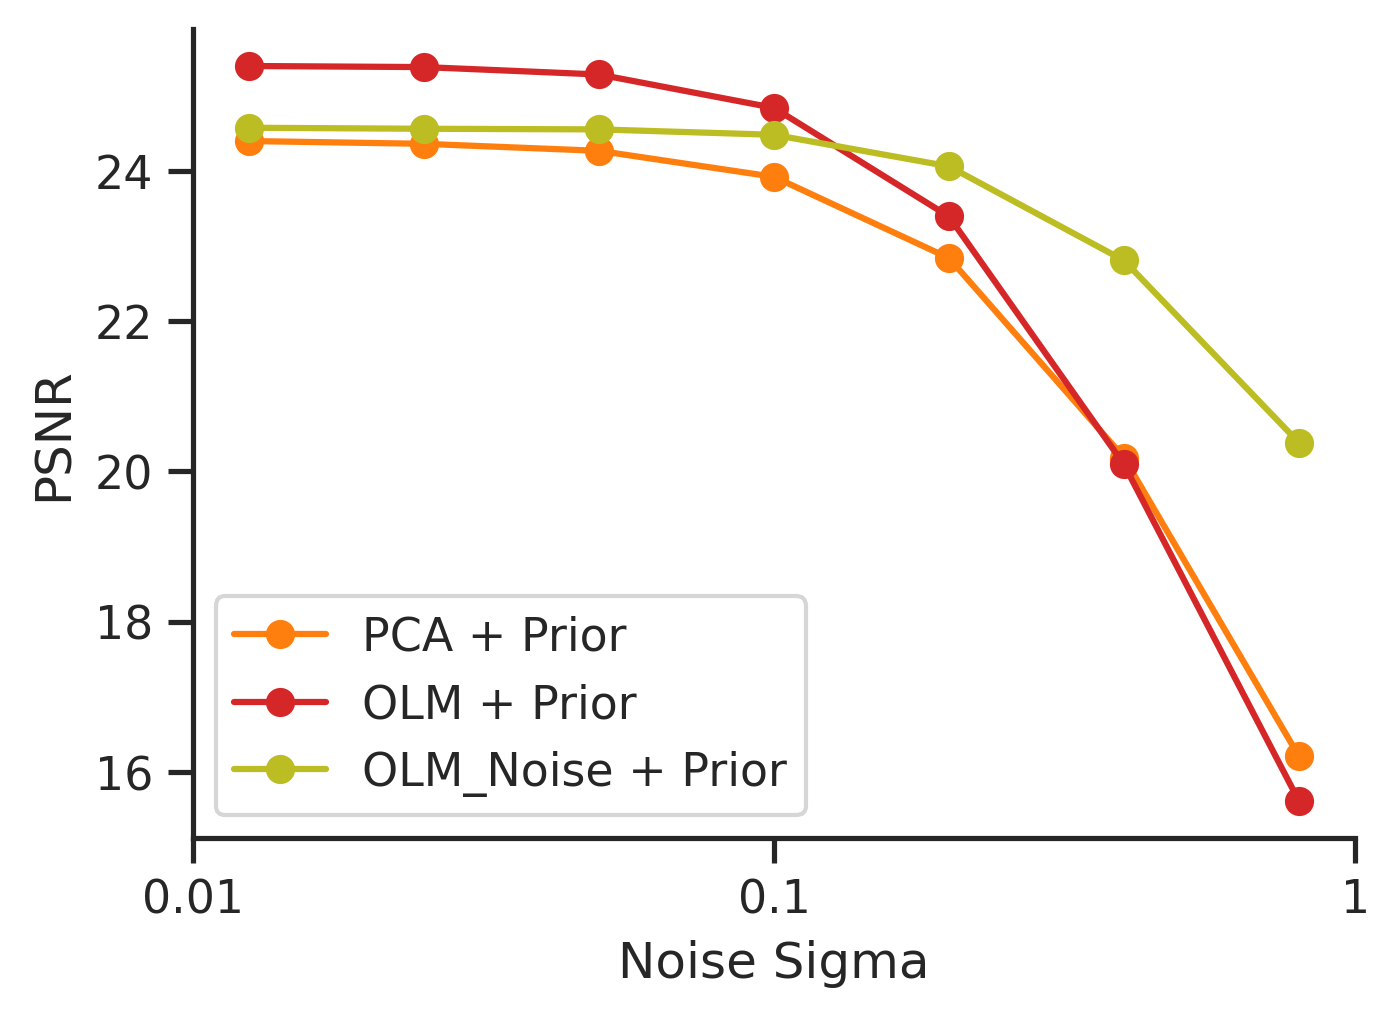

In [25]:
fig = plt.figure(figsize=(5, 3.5))
ax = plt.subplot()

plt.plot(noise_sigma, psnr_vals[0, :], 
         '-o', color='tab:orange', label='PCA + Prior')
plt.plot(noise_sigma, psnr_vals[1, :], 
         '-o', color='tab:red', label='OLM + Prior')
plt.plot(noise_sigma, psnr_vals[2, :], 
         '-o', color='tab:olive', label='OLM_Noise + Prior')

plt.xscale('log')
plt.xlabel('Noise Sigma')
plt.ylabel('PSNR')
plt.minorticks_off()
plt.xticks([0.01, 0.1, 1])
ax.set_xticklabels(([0.01, 0.1, 1]))
plt.legend()

plt.show()
fig.savefig('additive_noise_opt.pdf', format='pdf', bbox_inches='tight')

In [26]:
target_shape = [-1, im_size[0], im_size[2], im_size[1]]
noise_image = opt_noise.reshape(target_shape).transpose([0, 3, 2, 1])

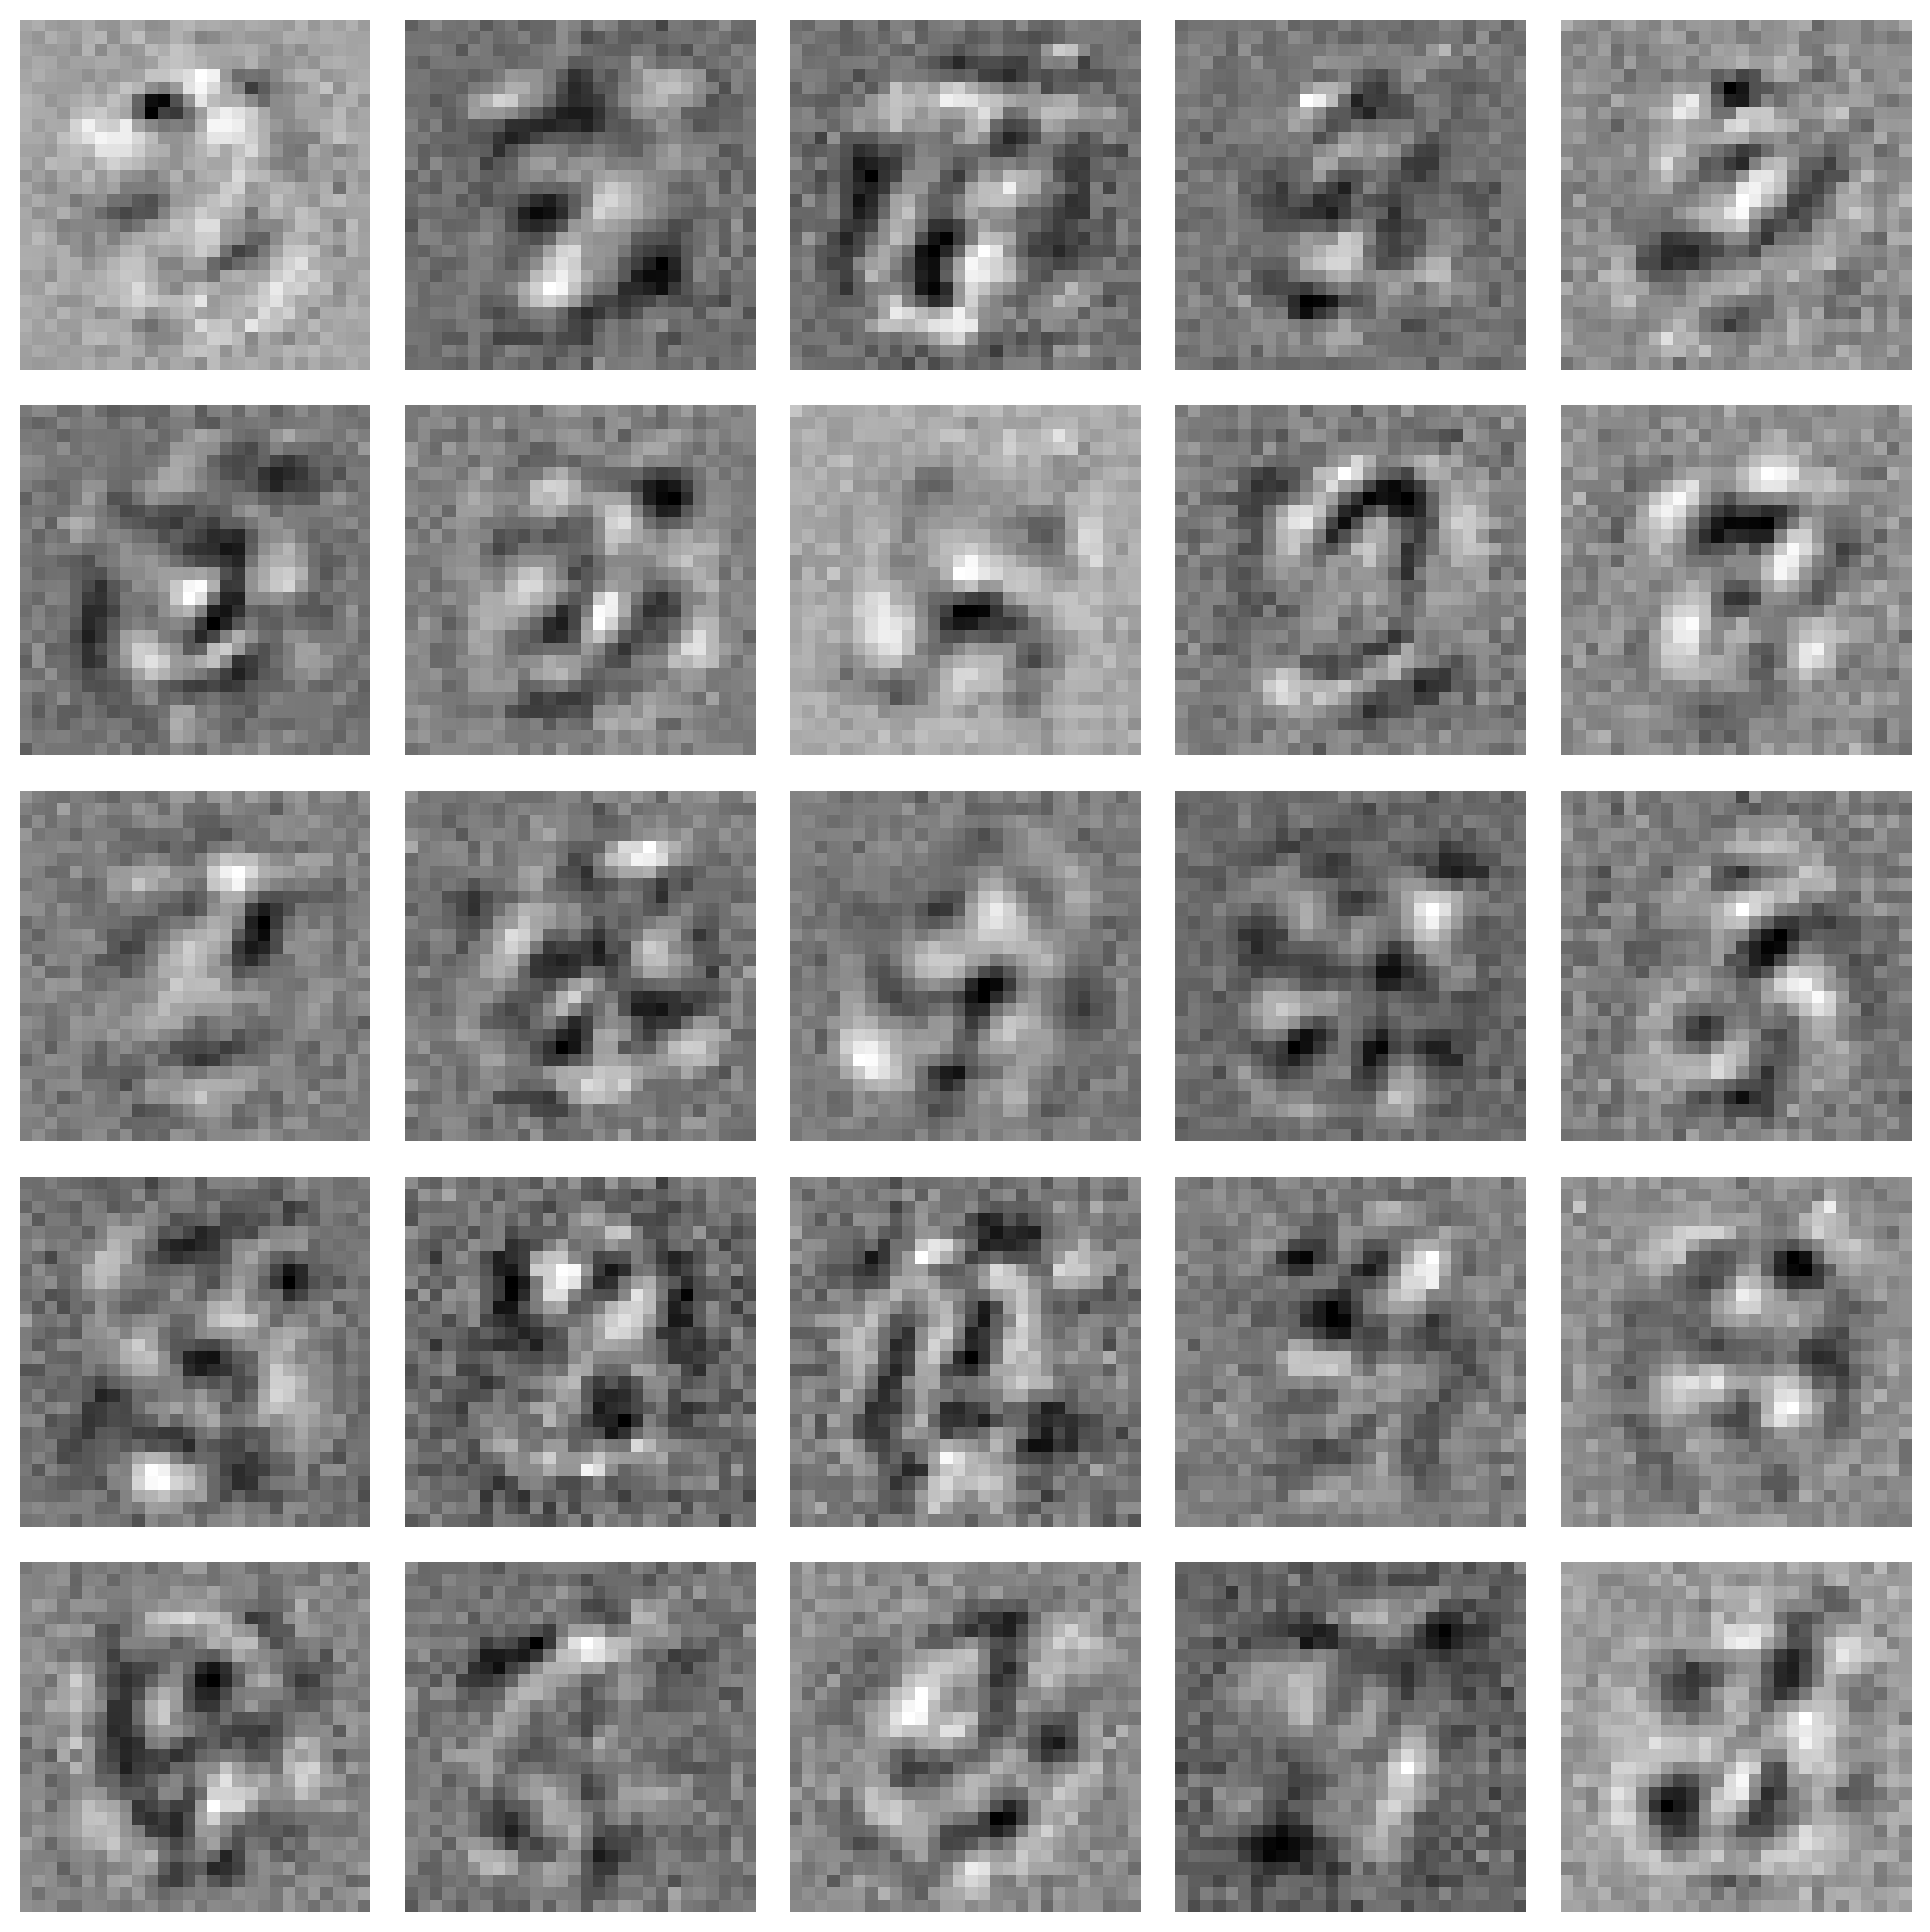

In [28]:
n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = noise_image[idx]
    image = image - np.min(image)
    image = image / np.max(image)

    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')

fig.tight_layout()
fig.savefig('noise_visul.pdf', format='pdf', bbox_inches='tight')